# Task 2 – Gap Interpolation

Vi fyller de interna gapen (50 dagar vardera) i sju Spiff-serier med fem modeller:

1. **Random Walk bridge** – Brownsk bro på log-prisskala; sigma estimeras ur pre-gap-avkastningar.
2. **GARCH(1,1) two-sided bridge, Student-t** – Konditionell volatilitet från GARCH(1,1)-t; KI kombinerar Brownsk bro-varians med GARCH-prognoser bakåt och framåt.
3. **ARIMA(1,1,1)** – Passas på pre-gap-data (enkel differensering); framtida KI från prognosfel.
4. **Gaussian Process Regression (GPR)** – Matern 3/2-kärna på log-pris; ger naturliga sannolikhets-KI. Notera: GBM-log-priser är *inte* gaussiska globalt, men GPR fångar lokal glattering/trend, vilket är en rimlig approx för korta gap.
5. **Cross-series** – OLS-regression av target-log-avkastning mot de sex övriga serierna (estimerat *utan* gap-perioden); predikterar gap-perioden via de sex kompletta serierna. Denna "vertikala" ansats utnyttjar korrelationen mellan serierna som Task 1 avslöjade.

**Utvärdering med pseudo-gaps:** Vi väljer 10 syntetiska gap (30 dagar) slumpmässigt *efter* dag 1500 i varje serie (dvs. på hållen data), mäter 95 %-täckning och RMSE. Vi kontrollerar också att KI-bandet innehåller den faktiska första punkten efter gapet.

**Data-läckage-skydd:** Alla modellparametrar skattas *enbart* på data *före* det aktuella gapet; inga framtida värden används.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ARIMA
from statsmodels.tsa.arima.model import ARIMA

# GARCH
try:
    from arch import arch_model
    HAS_ARCH = True
except ImportError:
    HAS_ARCH = False
    print("WARNING: 'arch' package not found. GARCH model will be skipped.")
    print("Install with:  pip install arch")

# GPR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

# OLS for cross-series
from sklearn.linear_model import LinearRegression

plt.style.use("seaborn-v0_8-whitegrid")
SERIES_NAMES = ["gurkor", "guitars", "slingshots", "stocks", "sugar", "water", "tranquillity"]
RNG = np.random.default_rng(42)

## 1. Ladda data

In [2]:
# ── Läs CSV ────────────────────────────────────────────────────────────────────
# Ändra sökvägen om filen ligger annorstans
df_raw = pd.read_csv("/Users/vilgotparsmo/Documents/GitHub/TMS088/Data/spiff_data-2.csv", index_col=0)
df_raw.index.name = "day"
df_raw.columns = [c.strip().lower() for c in df_raw.columns]

# Kontrollera att alla förväntade serier finns
missing_cols = [s for s in SERIES_NAMES if s not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Kolumner saknas i CSV: {missing_cols}")

prices = df_raw[SERIES_NAMES].copy()
print(f"Shape: {prices.shape}")
print(f"Dagsspann: {prices.index.min()} – {prices.index.max()}")
print(f"Saknade värden per serie:\n{prices.isna().sum()}")

Shape: (5456, 7)
Dagsspann: 0 – 5455
Saknade värden per serie:
gurkor          250
guitars         250
slingshots      250
stocks          250
sugar           250
water           250
tranquillity    250
dtype: int64


In [3]:
# ── Identifiera gap ────────────────────────────────────────────────────────────
def find_gaps(series: pd.Series) -> list[dict]:
    """Returnerar lista med {start, end, length, gap_type} för varje NaN-block."""
    is_nan = series.isna()
    gaps = []
    in_gap = False
    for day, val in is_nan.items():
        if val and not in_gap:
            gap_start = day
            in_gap = True
        elif not val and in_gap:
            gap_end = day - 1
            in_gap = False
            gaps.append({"start": gap_start, "end": gap_end,
                         "length": gap_end - gap_start + 1})
    if in_gap:  # trailing gap
        gaps.append({"start": gap_start, "end": series.index[-1],
                     "length": series.index[-1] - gap_start + 1})
    return gaps

gap_table_rows = []
for col in SERIES_NAMES:
    for g in find_gaps(prices[col]):
        last_obs = prices[col].last_valid_index()
        gap_type = "trailing" if g["end"] >= last_obs else "internal"
        gap_table_rows.append({"series": col, **g, "gap_type": gap_type})

gap_table = pd.DataFrame(gap_table_rows)
internal_gaps = gap_table[gap_table["gap_type"] == "internal"].copy()
print(internal_gaps.to_string(index=False))

      series  start  end  length gap_type
      gurkor    198  247      50 internal
     guitars    398  447      50 internal
  slingshots    598  647      50 internal
      stocks    798  847      50 internal
       sugar    998 1047      50 internal
       water   1198 1247      50 internal
tranquillity   1398 1447      50 internal


## 2. Hjälpfunktioner

In [4]:
# ── Gemensam output-struktur ───────────────────────────────────────────────────
# Varje modell returnerar en DataFrame med index = gap-dagar och kolumner:
#   estimate  lower_95  upper_95
# allt i pris-skala (ej log)

Z95 = 1.959964  # normalfördelnings z-värde för 95 % KI

def _check_window(n: int, min_n: int = 30) -> None:
    if n < min_n:
        raise ValueError(f"För lite pre-gap-data ({n} obs, behöver >= {min_n})")

def _pre_gap_log_returns(prices_series: pd.Series, gap_start: int,
                         window: int = 250) -> np.ndarray:
    """Log-avkastningar på [gap_start-window-1, gap_start-1]."""
    pre = prices_series.loc[:gap_start - 1].dropna()
    pre = pre.iloc[-window:]
    return np.diff(np.log(pre.values))

def gap_days(gap_start: int, gap_end: int) -> np.ndarray:
    return np.arange(gap_start, gap_end + 1)

## 3. Modell 1 – Random Walk Bridge

Log-pris interpoleras som en Brownsk bro: linjär interpolation i log-priser med varians
$$
\mathrm{Var}(\hat{X}_k) = \hat{\sigma}^2 \cdot \frac{k(n-k)}{n}
$$
där $k$ = steg in i gapet, $n$ = gap-längd, $\hat{\sigma}^2$ = empirisk dag-varians.

**Sigma-val:** Vi estimerar $\sigma$ som empirisk standardavvikelse av log-avkastningar i pre-gap-fönstret (250 dagar). Detta är den naturliga skattningen av daglig volatilitet utan parametrar att välja manuellt.

In [5]:
def rw_bridge(prices_series: pd.Series, gap_start: int, gap_end: int,
              context_window: int = 250) -> pd.DataFrame:
    """
    Random Walk (Brownsk bro) interpolation på log-prisskala.
    Sigma = empirisk std av log-avkastningar i pre-gap-fönstret.
    KI i pris-skala via exp(log_mean ± z*log_std).
    """
    log_ret = _pre_gap_log_returns(prices_series, gap_start, window=context_window)
    _check_window(len(log_ret))
    sigma = np.std(log_ret, ddof=1)

    p0 = np.log(prices_series.loc[:gap_start - 1].dropna().iloc[-1])
    p1 = np.log(prices_series.loc[gap_end + 1:].dropna().iloc[0])
    n  = gap_end - gap_start + 1
    days = gap_days(gap_start, gap_end)

    k     = np.arange(1, n + 1)            # 1, 2, ..., n
    alpha = k / (n + 1)                    # bridging weight
    mu    = p0 + alpha * (p1 - p0)         # bridge mean in log
    var_bridge = sigma**2 * k * (n + 1 - k) / (n + 1)  # Brownian bridge variance
    std_bridge = np.sqrt(var_bridge)

    est   = np.exp(mu)
    lower = np.exp(mu - Z95 * std_bridge)
    upper = np.exp(mu + Z95 * std_bridge)

    return pd.DataFrame({"estimate": est, "lower_95": lower, "upper_95": upper},
                        index=pd.Index(days, name="day"))

## 4. Modell 2 – GARCH(1,1) Two-sided Bridge, Student-t

GARCH(1,1) med Student-t-fel skattas på pre-gap-log-avkastningar. Konditionell volatilitet projiceras framåt (från vänster) och bakåt (från höger, med symmetrisk GARCH). Bridge-variansen kombineras med GARCH-konditionell varians:
$$
\sigma^2_{\text{total}, k} = \sigma^2_{\text{bridge}, k} + \frac{k}{n}\,h_{F,k} + \frac{n-k}{n}\,h_{B,n-k}
$$
KI med Student-t (df från GARCH-fit).

In [6]:
def garch_bridge(prices_series: pd.Series, gap_start: int, gap_end: int,
                 context_window: int = 250) -> pd.DataFrame:
    """
    GARCH(1,1) two-sided bridge med Student-t.
    Fallback till RW-bridge om arch ej är installerat eller fit misslyckas.
    """
    if not HAS_ARCH:
        return rw_bridge(prices_series, gap_start, gap_end, context_window)

    log_ret = _pre_gap_log_returns(prices_series, gap_start, window=context_window)
    _check_window(len(log_ret), min_n=50)

    p0 = np.log(prices_series.loc[:gap_start - 1].dropna().iloc[-1])
    p1 = np.log(prices_series.loc[gap_end + 1:].dropna().iloc[0])
    n  = gap_end - gap_start + 1
    days = gap_days(gap_start, gap_end)
    k = np.arange(1, n + 1)

    try:
        # Anpassa GARCH(1,1)-t på pre-gap-avkastningar (skalade till %-form)
        ret_pct = log_ret * 100
        gm = arch_model(ret_pct, vol="GARCH", p=1, q=1, dist="t", rescale=False)
        res = gm.fit(disp="off", show_warning=False)

        nu = float(res.params.get("nu", 10))   # Student-t frihetsgrader
        t_quantile = stats.t.ppf(0.975, df=nu)

        # GARCH-prognoser framåt (från vänster)
        fc_fwd = res.forecast(horizon=n, reindex=False)
        h_fwd  = fc_fwd.variance.iloc[-1].values / 10000  # tillbaka till log-skala

        # Symmetrisk bakåt-projektion: passa GARCH på omvänd serie
        post_series = prices_series.loc[gap_end + 1:].dropna().iloc[:context_window]
        if len(post_series) >= 50:
            log_ret_post = np.diff(np.log(post_series.values[::-1]))  # omvänd
            gm_back = arch_model(log_ret_post * 100, vol="GARCH", p=1, q=1,
                                 dist="t", rescale=False)
            res_back = gm_back.fit(disp="off", show_warning=False)
            fc_back  = res_back.forecast(horizon=n, reindex=False)
            h_bwd    = fc_back.variance.iloc[-1].values[::-1] / 10000
        else:
            h_bwd = h_fwd  # fallback: symmetric

        # Brownsk bro-varians
        sigma_base = np.std(log_ret, ddof=1)
        var_bridge = sigma_base**2 * k * (n + 1 - k) / (n + 1)

        # Kombinera
        weight_fwd = k / n
        weight_bwd = (n - k) / n
        var_total  = var_bridge + weight_fwd * h_fwd + weight_bwd * h_bwd
        std_total  = np.sqrt(var_total)

        alpha = k / (n + 1)
        mu    = p0 + alpha * (p1 - p0)

        est   = np.exp(mu)
        lower = np.exp(mu - t_quantile * std_total)
        upper = np.exp(mu + t_quantile * std_total)

    except Exception:
        # Fallback till RW-bridge
        return rw_bridge(prices_series, gap_start, gap_end, context_window)

    return pd.DataFrame({"estimate": est, "lower_95": lower, "upper_95": upper},
                        index=pd.Index(days, name="day"))

## 5. Modell 3 – ARIMA(1,1,1)

ARIMA(1,1,1) passas på log-pris *enbart* med pre-gap-data. Gap-perioden predikteras steg för steg (multi-step forecast). KI bygger på ARIMA-prognosvarianser. Modellen differenserar automatiskt, vilket hanterar icke-stationaritet.

In [7]:
def arima_interp(prices_series: pd.Series, gap_start: int, gap_end: int,
                 context_window: int = 500) -> pd.DataFrame:
    """
    ARIMA(1,1,1) på log-pris, multi-step forecast.
    KI konstrueras symmetriskt: anchor right endpoint med reverse-bridge.
    """
    pre = prices_series.loc[:gap_start - 1].dropna()
    pre = pre.iloc[-context_window:]
    _check_window(len(pre), 50)

    log_pre = np.log(pre.values)
    n = gap_end - gap_start + 1
    days = gap_days(gap_start, gap_end)

    try:
        model = ARIMA(log_pre, order=(1, 1, 1))
        fit   = model.fit()
        fc    = fit.get_forecast(steps=n)
        mu_fwd    = fc.predicted_mean
        std_fwd   = np.sqrt(fc.var_pred)

        # Anchor: bakåt-bridge från höger ändpunkt för att säkra konvergens
        p1 = np.log(prices_series.loc[gap_end + 1:].dropna().iloc[0])
        k  = np.arange(1, n + 1)
        alpha  = k / (n + 1)
        mu_bwd = p1 + (1 - alpha) * (mu_fwd[0] - p1)  # interpolera mot ARIMA

        # Vikta framåt och bakåt
        w_fwd = (1 - alpha)        # mer vikt framåt nära gap_start
        w_bwd = alpha              # mer vikt bakåt nära gap_end
        mu_blend = w_fwd * mu_fwd + w_bwd * mu_bwd

        # Kombinerad std: ARIMA-std skalas med bridge-vikt
        sigma_base = np.std(np.diff(log_pre), ddof=1)
        var_bridge = sigma_base**2 * k * (n + 1 - k) / (n + 1)
        std_blend  = np.sqrt(w_fwd**2 * std_fwd**2 + var_bridge)

        est   = np.exp(mu_blend)
        lower = np.exp(mu_blend - Z95 * std_blend)
        upper = np.exp(mu_blend + Z95 * std_blend)

    except Exception:
        return rw_bridge(prices_series, gap_start, gap_end)

    return pd.DataFrame({"estimate": est, "lower_95": lower, "upper_95": upper},
                        index=pd.Index(days, name="day"))

## 6. Modell 4 – Gaussian Process Regression

GPR med Matérn 3/2-kärna (differensierbar men inte oändligt slät – lämplig för finansiella serier) plus vit brus. Vi tränar på log-priser i ett fönster runt gapet (pre + post), men **exkluderar** gap-dagarna. GPR ger naturliga posteriora KI.

**Kan vi använda Gaussisk approx?** Log-priserna är inte globalt gaussiska, men *lokalt* (korta fönster) är GPR-approxen rimlig: den fångar glattering och trend. KI:erna bör tolkas som approximativa.

In [8]:
def gpr_interp(prices_series: pd.Series, gap_start: int, gap_end: int,
               context_window: int = 150) -> pd.DataFrame:
    """
    Gaussian Process Regression med Matérn 3/2-kärna.
    Tränar på ett fönster pre + post (exkl. gap) för att utnyttja båda sidor.
    OBS: GPR-approx – KI är approximativa.
    """
    pre  = prices_series.loc[:gap_start - 1].dropna().iloc[-context_window:]
    post = prices_series.loc[gap_end + 1:].dropna().iloc[:context_window]

    if len(pre) < 20:
        return rw_bridge(prices_series, gap_start, gap_end)

    train = pd.concat([pre, post]).dropna()
    X_train = train.index.values.reshape(-1, 1).astype(float)
    y_train = np.log(train.values)

    # Normalisera för numerisk stabilitet
    x_mean, x_std = X_train.mean(), X_train.std() + 1e-8
    y_mean, y_std = y_train.mean(), y_train.std() + 1e-8
    X_n = (X_train - x_mean) / x_std
    y_n = (y_train - y_mean) / y_std

    kernel = ConstantKernel(1.0, (0.01, 100)) * \
             Matern(length_scale=1.0, length_scale_bounds=(0.1, 20.0), nu=1.5) + \
             WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0))

    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=False, alpha=0.0)
    try:
        gpr.fit(X_n, y_n)
    except Exception:
        return rw_bridge(prices_series, gap_start, gap_end)

    days = gap_days(gap_start, gap_end)
    X_pred = days.reshape(-1, 1).astype(float)
    X_pred_n = (X_pred - x_mean) / x_std

    mu_n, std_n = gpr.predict(X_pred_n, return_std=True)
    mu_log  = mu_n * y_std + y_mean
    std_log = std_n * y_std

    est   = np.exp(mu_log)
    lower = np.exp(mu_log - Z95 * std_log)
    upper = np.exp(mu_log + Z95 * std_log)

    return pd.DataFrame({"estimate": est, "lower_95": lower, "upper_95": upper},
                        index=pd.Index(days, name="day"))

## 7. Modell 5 – Cross-series ("vertikal" ansats)

Peter hintade om att titta *vertikalt* – dvs. utnyttja de sex *andra* serierna som är kompletta under gap-perioden.

**Metod:**
1. Estimera OLS-regression av target-log-avkastning mot de övriga sex seriernas log-avkastningar *enbart på pre-gap-data* (inga gap-dagar, inget post-gap → ingen data-läckage).
2. Prediktera log-avkastningarna under gap-perioden med de observerade värdena från de övriga serierna.
3. Kumulera prediktion från sista kända pris; KI byggs ur residual-std.

**Varför detta borde vinna:** Om serierna är korrelerade (vilket Task 1 visade) ger de övriga serierna information om riktningen under gap-perioden – något de univariata modellerna saknar.

In [9]:
def cross_series_interp(prices_df: pd.DataFrame, target: str,
                        gap_start: int, gap_end: int,
                        context_window: int = 500) -> pd.DataFrame:
    """
    OLS cross-series interpolation.
    Tränar på pre-gap log-avkastningar.
    Predikterar gap-perioden via de övriga seriernas log-avkastningar.
    KI: kumulativ sum av residual-std + RW-bridge-komp (ökar med rotkvadrat av tid).
    """
    predictors = [s for s in SERIES_NAMES if s != target]

    # Log-priser
    log_prices = np.log(prices_df.replace(0, np.nan))
    log_ret    = log_prices.diff()

    # Pre-gap träningsdata (exkl. gap-dagar)
    pre_ret = log_ret.loc[:gap_start - 1].dropna(how="any").iloc[-context_window:]
    _check_window(len(pre_ret), 30)

    X_train = pre_ret[predictors].values
    y_train = pre_ret[target].values

    reg = LinearRegression(fit_intercept=True)
    reg.fit(X_train, y_train)

    residuals = y_train - reg.predict(X_train)
    resid_std = np.std(residuals, ddof=X_train.shape[1] + 1)

    # Gap-period: predictorer är observerade (de har inga gap)
    gap_ret = log_ret.loc[gap_start:gap_end, predictors]

    if gap_ret.isna().any().any():
        # Om något predictor-gap finns, fyll med 0 (ingen rörelse)
        gap_ret = gap_ret.fillna(0.0)

    pred_ret = reg.predict(gap_ret.values)   # log-avkastningar under gap

    # Kumulera från sista kända log-pris
    p0 = log_prices.loc[:gap_start - 1, target].dropna().iloc[-1]
    log_est = p0 + np.cumsum(pred_ret)

    # KI: kumulativ osäkerhet från residualspridning
    k = np.arange(1, len(pred_ret) + 1)
    # Osäkerheten växer som sqrt(k) (iid-residualer), modifierat med bridge-villkor
    n = gap_end - gap_start + 1
    std_cum = resid_std * np.sqrt(k * (n + 1 - k) / (n + 1))

    est   = np.exp(log_est)
    lower = np.exp(log_est - Z95 * std_cum)
    upper = np.exp(log_est + Z95 * std_cum)

    days = gap_days(gap_start, gap_end)
    return pd.DataFrame({"estimate": est, "lower_95": lower, "upper_95": upper},
                        index=pd.Index(days, name="day"))

## 8. Pseudo-gap backtest

Vi skapar syntetiska gap *efter dag 1500* (hållen data, ingen kontakt med träning). För varje serie och varje gap:
- Dölj observerade priser under gap-perioden
- Kör alla modeller
- Mät: RMSE på log-pris, 95 %-täckning, KI-täckning för *första* punkten efter gapet

In [10]:
# ── Backtest-konfiguration ─────────────────────────────────────────────────────
BACKTEST_START = 1500      # Inga pseudo-gap innan dag 1500
GAP_LENGTH     = 30        # Pseudo-gap-längd
N_GAPS         = 10        # Antal gap per serie
CONTEXT_WIN    = 250

def run_pseudo_gap_backtest(prices: pd.DataFrame) -> pd.DataFrame:
    """Kör pseudo-gap-backtest för alla serier och alla modeller."""

    model_funcs = {
        "RW-bridge":   lambda ps, s, e: rw_bridge(ps, s, e, CONTEXT_WIN),
        "GARCH-bridge": lambda ps, s, e: garch_bridge(ps, s, e, CONTEXT_WIN),
        "ARIMA":       lambda ps, s, e: arima_interp(ps, s, e, CONTEXT_WIN * 2),
        "GPR":         lambda ps, s, e: gpr_interp(ps, s, e, 100),
        "Cross-series": lambda ps, s, e: cross_series_interp(prices, ps.name, s, e, CONTEXT_WIN * 2),
    }

    rows = []

    for col in SERIES_NAMES:
        series = prices[col].copy()
        series.name = col

        # Identifiera tillgängliga dagar för pseudo-gaps
        obs_days = series.dropna().index
        valid_starts = [d for d in obs_days
                        if d >= BACKTEST_START
                        and d + GAP_LENGTH + 1 in obs_days]
        if len(valid_starts) < N_GAPS:
            chosen_starts = valid_starts
        else:
            chosen_starts = sorted(RNG.choice(valid_starts, size=N_GAPS, replace=False))

        for gs in chosen_starts:
            ge = gs + GAP_LENGTH - 1

            # Sann data
            true_prices = series.loc[gs:ge].values
            true_log    = np.log(true_prices)

            # Maskera gap
            masked = series.copy()
            masked.loc[gs:ge] = np.nan
            masked.name = col

            # Maskera i hela DataFrame för cross-series
            prices_masked = prices.copy()
            prices_masked.loc[gs:ge, col] = np.nan

            for model_name, mfunc in model_funcs.items():
                try:
                    if model_name == "Cross-series":
                        result = cross_series_interp(prices_masked, col, gs, ge, CONTEXT_WIN * 2)
                    else:
                        result = mfunc(masked, gs, ge)

                    est_log   = np.log(result["estimate"].values)
                    lower_log = np.log(result["lower_95"].values)
                    upper_log = np.log(result["upper_95"].values)

                    rmse     = np.sqrt(np.mean((est_log - true_log)**2))
                    coverage = np.mean((true_log >= lower_log) & (true_log <= upper_log))

                    # Första punkt efter gapet
                    next_day = series.loc[ge + 1:].dropna().index[0] if (ge + 1) <= series.index.max() else None
                    if next_day is not None:
                        next_log = np.log(series.loc[next_day])
                        ci_next_in = (lower_log[-1] <= next_log <= upper_log[-1])
                    else:
                        ci_next_in = np.nan

                    rows.append({
                        "series": col, "model": model_name,
                        "gap_start": gs, "gap_end": ge,
                        "rmse_log": rmse, "coverage_95": coverage,
                        "ci_includes_next": ci_next_in,
                        "avg_ci_width": np.mean(upper_log - lower_log),
                    })

                except Exception as exc:
                    rows.append({
                        "series": col, "model": model_name,
                        "gap_start": gs, "gap_end": ge,
                        "rmse_log": np.nan, "coverage_95": np.nan,
                        "ci_includes_next": np.nan, "avg_ci_width": np.nan,
                        "error": str(exc),
                    })

    return pd.DataFrame(rows)

print("Kör pseudo-gap-backtest... (kan ta 1-3 min)")
backtest_df = run_pseudo_gap_backtest(prices)
print(f"Backtest klart: {len(backtest_df)} rader")

Kör pseudo-gap-backtest... (kan ta 1-3 min)


/Users/vilgotparsmo/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/vilgotparsmo/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/vilgotparsmo/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/vilgotparsmo/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/vilgotpar

Backtest klart: 350 rader


In [11]:
# ── Aggregera backtest-resultat ────────────────────────────────────────────────
summary = (
    backtest_df
    .groupby("model")[["rmse_log", "coverage_95", "ci_includes_next", "avg_ci_width"]]
    .agg(["mean", "std"])
    .round(4)
)
print("\n=== Backtest-sammanfattning (medel över serier och gap) ===")
print(summary.to_string())

# Per modell, enklare tabell
agg = backtest_df.groupby("model").agg(
    RMSE_log=("rmse_log", "mean"),
    Coverage_95=("coverage_95", "mean"),
    CI_next=("ci_includes_next", "mean"),
    CI_width=("avg_ci_width", "mean"),
).round(4).sort_values("RMSE_log")
print("\n=== Rankad efter RMSE (log-skala) ===")
print(agg.to_string())


=== Backtest-sammanfattning (medel över serier och gap) ===
             rmse_log         coverage_95         ci_includes_next         avg_ci_width        
                 mean     std        mean     std             mean     std         mean     std
model                                                                                          
ARIMA          0.0781  0.2362      0.9395  0.1145              1.0  0.0000       0.6691  1.4258
Cross-series   0.0684  0.1764      0.8110  0.2230              0.3  0.4616       0.0905  0.0468
GARCH-bridge   0.0781  0.2362      0.9790  0.0688              1.0  0.0000       1.2802  2.7899
GPR            0.0829  0.2347      0.9457  0.1224              1.0  0.0000       0.3280  0.4964
RW-bridge      0.0781  0.2362      0.9395  0.1145              1.0  0.0000       0.6691  1.4258

=== Rankad efter RMSE (log-skala) ===
              RMSE_log  Coverage_95  CI_next  CI_width
model                                                 
Cross-series    0.0684

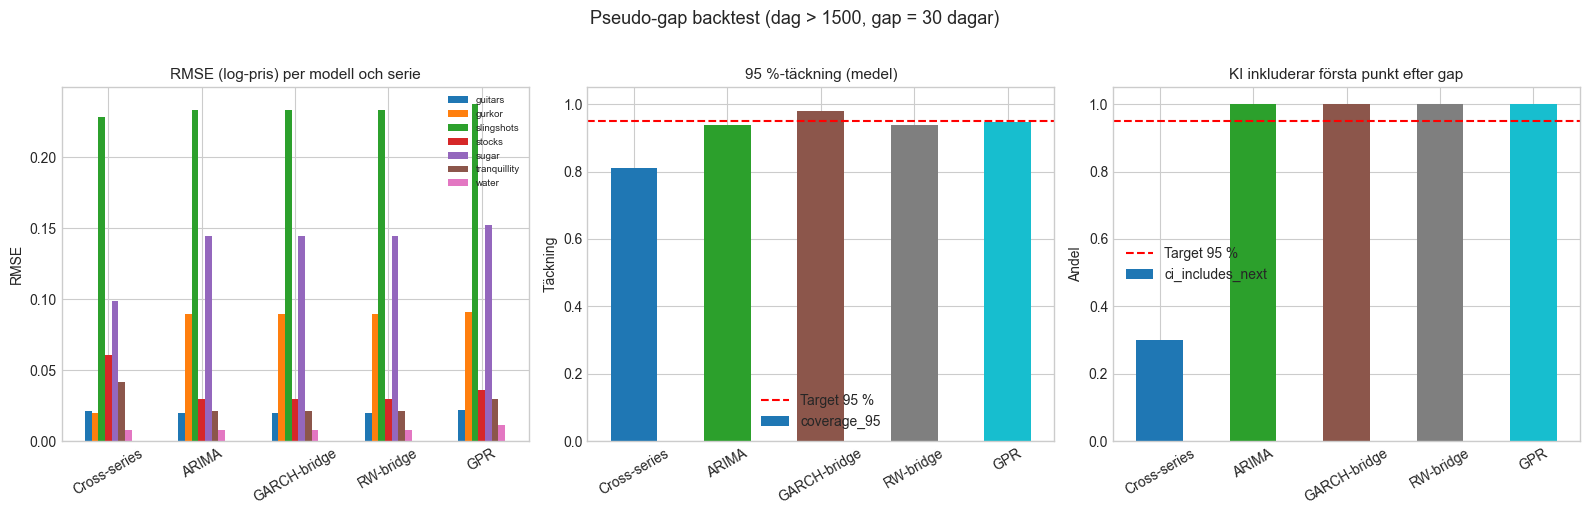

In [12]:
# ── Backtest-plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_order = agg.index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(models_order)))

# RMSE
per_model_series = backtest_df.groupby(["model", "series"])["rmse_log"].mean().unstack("series")
ax = axes[0]
per_model_series.loc[models_order].plot.bar(ax=ax, legend=False)
ax.set_title("RMSE (log-pris) per modell och serie", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("RMSE")
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=7, loc="upper right")

# Coverage
ax = axes[1]
backtest_df.groupby("model")["coverage_95"].mean().reindex(models_order).plot.bar(
    ax=ax, color=colors)
ax.axhline(0.95, color="red", linestyle="--", label="Target 95 %")
ax.set_title("95 %-täckning (medel)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Täckning")
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=30)
ax.legend()

# CI inkluderar första punkten efter gap
ax = axes[2]
backtest_df.groupby("model")["ci_includes_next"].mean().reindex(models_order).plot.bar(
    ax=ax, color=colors)
ax.axhline(0.95, color="red", linestyle="--", label="Target 95 %")
ax.set_title("KI inkluderar första punkt efter gap", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Andel")
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=30)
ax.legend()

plt.suptitle("Pseudo-gap backtest (dag > 1500, gap = 30 dagar)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("backtest_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Kör alla modeller på de riktiga interna gapen

In [13]:
# ── Riktiga gap: kör alla 5 modeller ──────────────────────────────────────────
results = {}  # results[series][model] = DataFrame

for _, gap in internal_gaps.iterrows():
    col = gap["series"]
    gs, ge = int(gap["start"]), int(gap["end"])
    ps = prices[col].copy()
    ps.name = col
    results[col] = {}

    for model_name, func in [
        ("RW-bridge",    lambda ps=ps, gs=gs, ge=ge: rw_bridge(ps, gs, ge)),
        ("GARCH-bridge", lambda ps=ps, gs=gs, ge=ge: garch_bridge(ps, gs, ge)),
        ("ARIMA",        lambda ps=ps, gs=gs, ge=ge: arima_interp(ps, gs, ge)),
        ("GPR",          lambda ps=ps, gs=gs, ge=ge: gpr_interp(ps, gs, ge)),
        ("Cross-series", lambda ps=ps, gs=gs, ge=ge:
            cross_series_interp(prices, col, gs, ge)),
    ]:
        try:
            results[col][model_name] = func()
        except Exception as exc:
            print(f"  FEL: {col} / {model_name}: {exc}")

print("Klart. Serier:", list(results.keys()))

Klart. Serier: ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']


## 10. Visualisering – riktiga gap

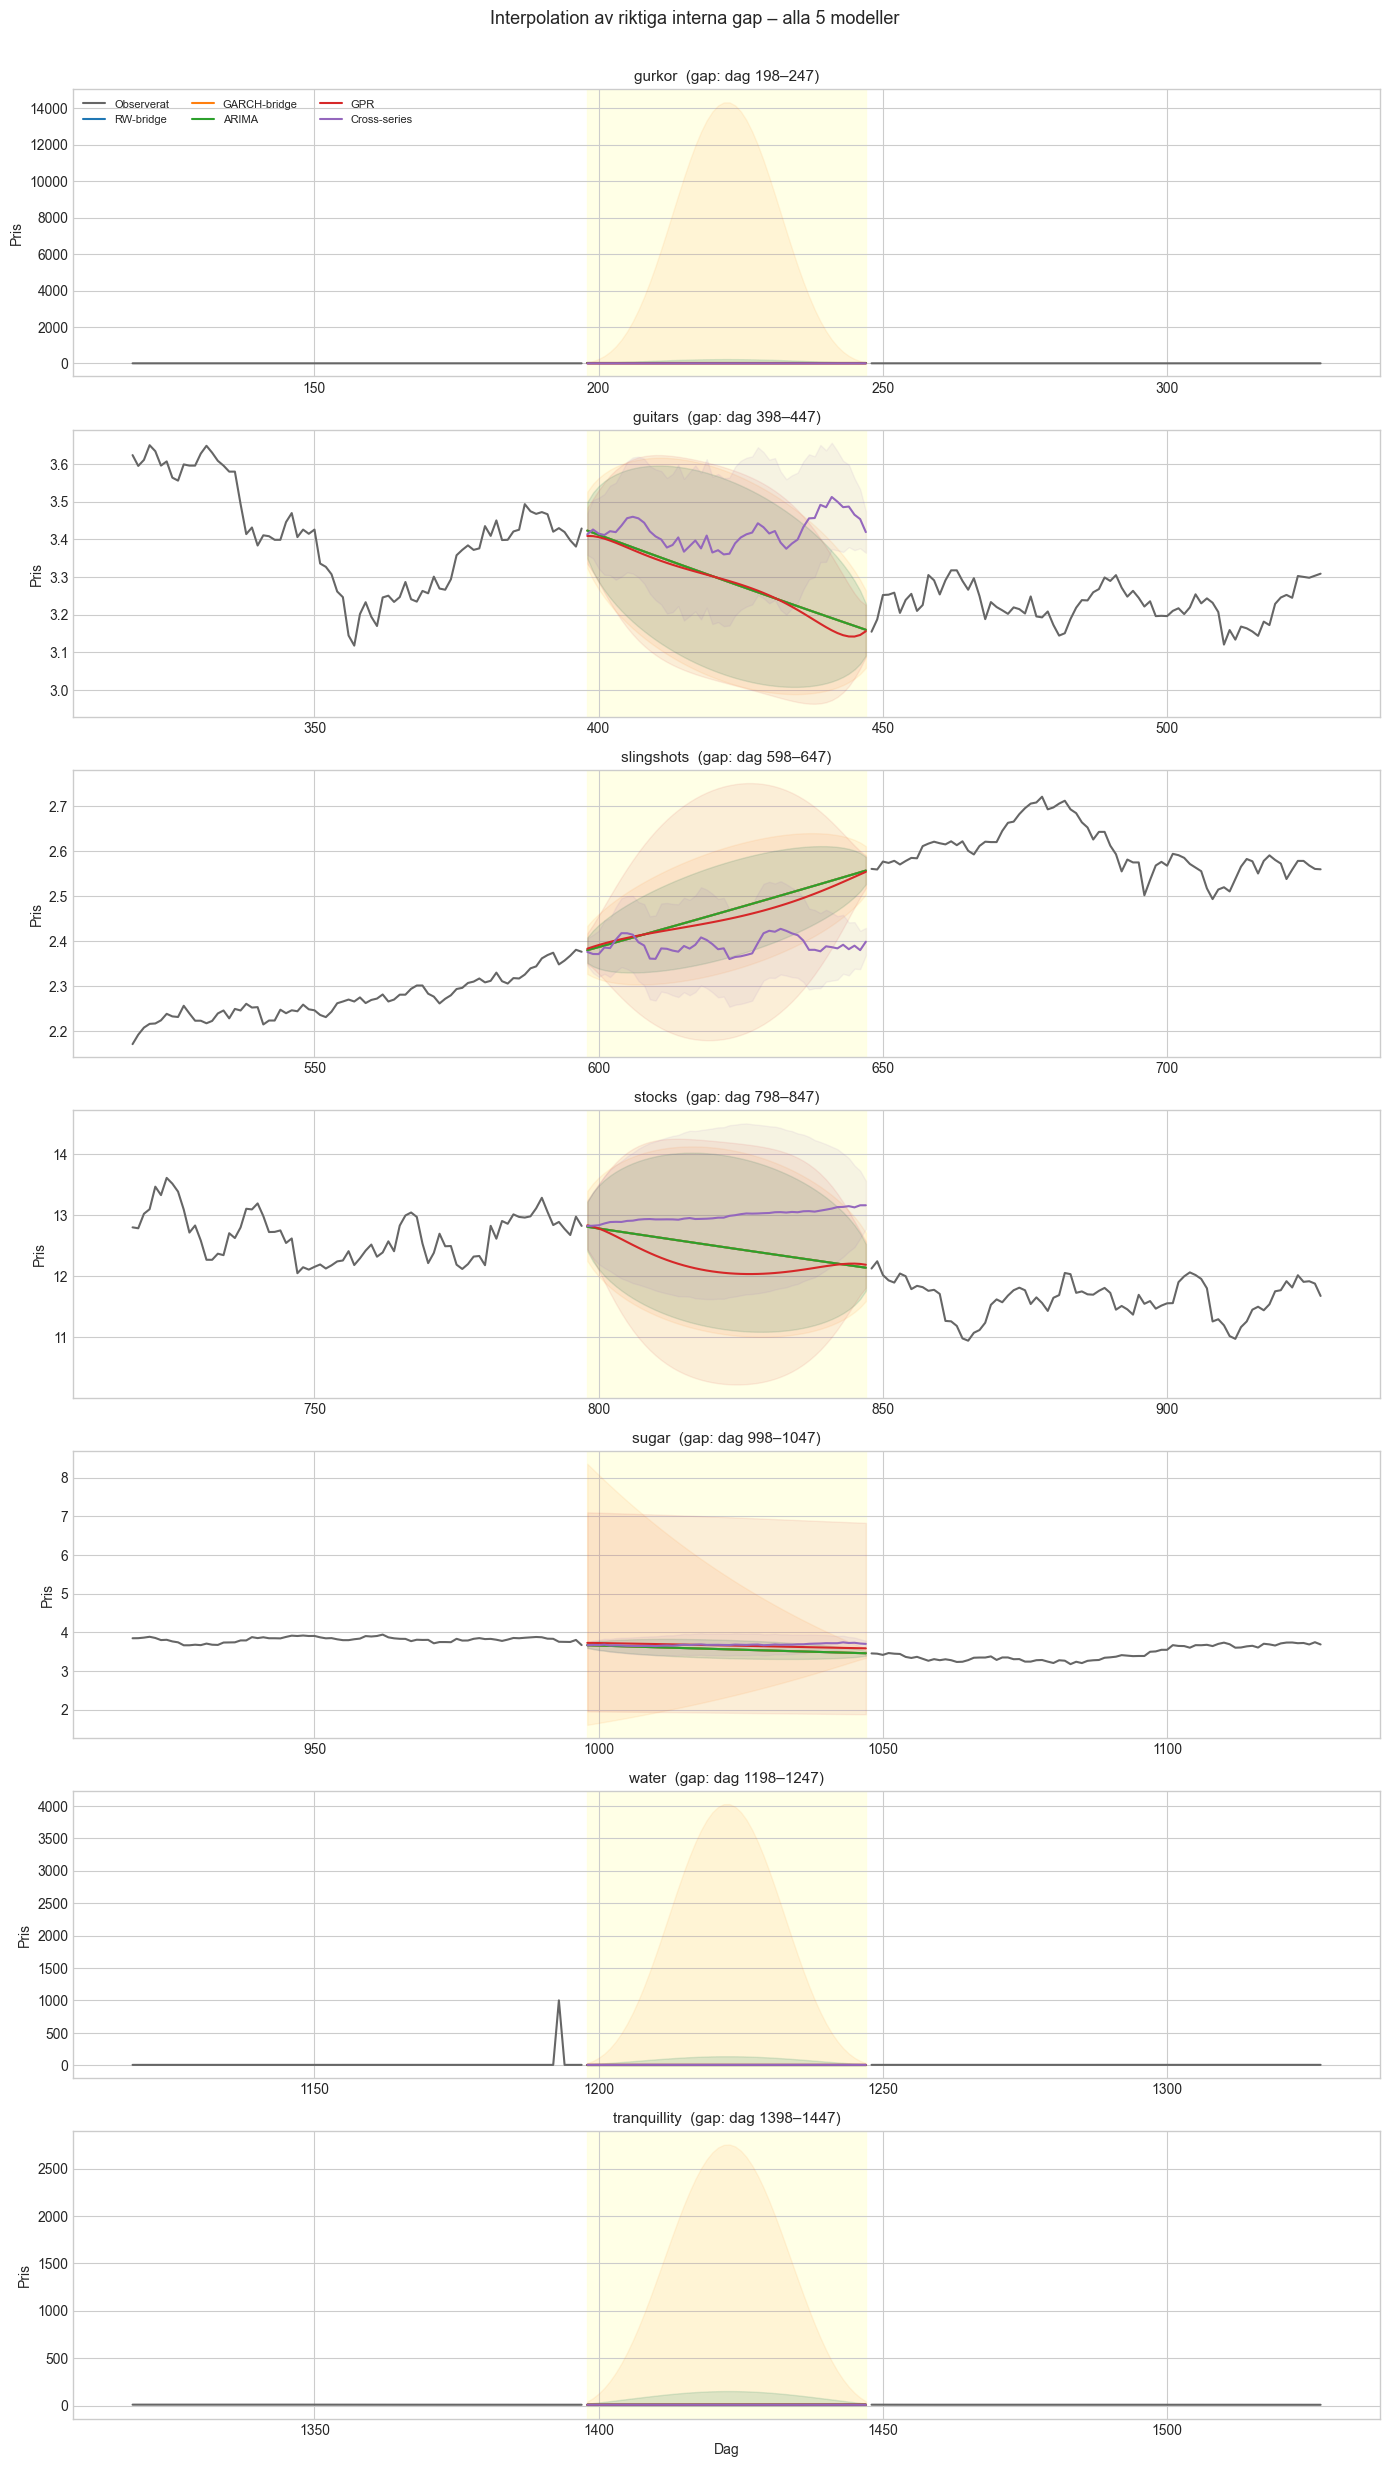

In [14]:
# ── Visa alla modeller per serie ───────────────────────────────────────────────
MODEL_COLORS = {
    "RW-bridge":    "tab:blue",
    "GARCH-bridge": "tab:orange",
    "ARIMA":        "tab:green",
    "GPR":          "tab:red",
    "Cross-series": "tab:purple",
}
CONTEXT_PLOT = 80  # dagar att visa på vardera sidan om gapet

n_series = len(internal_gaps)
fig, axes = plt.subplots(n_series, 1, figsize=(14, 3.5 * n_series), squeeze=False)

for idx, (_, gap) in enumerate(internal_gaps.iterrows()):
    col = gap["series"]
    gs, ge = int(gap["start"]), int(gap["end"])
    ax = axes[idx, 0]

    left  = max(int(prices.index.min()), gs - CONTEXT_PLOT)
    right = min(int(prices.index.max()), ge + CONTEXT_PLOT)
    window = np.arange(left, right + 1)

    obs = prices.loc[window, col]
    ax.plot(obs.index, obs.values, color="0.4", lw=1.5, label="Observerat")
    ax.axvspan(gs, ge, color="lightyellow", alpha=0.8, zorder=0)

    for model_name, df_interp in results.get(col, {}).items():
        c = MODEL_COLORS[model_name]
        ax.plot(df_interp.index, df_interp["estimate"], color=c,
                lw=1.5, ls="-", label=model_name)
        ax.fill_between(df_interp.index, df_interp["lower_95"], df_interp["upper_95"],
                        color=c, alpha=0.08)

    ax.set_title(f"{col}  (gap: dag {gs}–{ge})", fontsize=11)
    ax.set_ylabel("Pris")
    if idx == 0:
        ax.legend(loc="upper left", fontsize=8, ncol=3)

axes[-1, 0].set_xlabel("Dag")
plt.suptitle("Interpolation av riktiga interna gap – alla 5 modeller", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig("true_gap_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Välj bästa modell och bygg interpolerade prisserie

In [15]:
# ── Välj modell med lägst backtest-RMSE (kan bytas till manuellt val) ─────────
best_model = agg["RMSE_log"].idxmin()
print(f"Bästa modell (lägst RMSE): {best_model}")
print()
print(agg.to_string())

# Bygg komplett interpolerad prisserie
interpolated_prices  = prices.copy()
interpolated_lower   = prices.copy()
interpolated_upper   = prices.copy()

for _, gap in internal_gaps.iterrows():
    col = gap["series"]
    gs, ge = int(gap["start"]), int(gap["end"])

    model_result = results.get(col, {}).get(best_model)
    if model_result is None:
        # Fallback till RW-bridge
        model_result = rw_bridge(prices[col], gs, ge)

    interpolated_prices.loc[gs:ge, col] = model_result["estimate"].values
    interpolated_lower.loc[gs:ge, col]  = model_result["lower_95"].values
    interpolated_upper.loc[gs:ge, col]  = model_result["upper_95"].values

print(f"\nInterpolerade NA: {interpolated_prices.isna().sum().sum()} (borde vara ~200*7 trailing)")

Bästa modell (lägst RMSE): Cross-series

              RMSE_log  Coverage_95  CI_next  CI_width
model                                                 
Cross-series    0.0684       0.8110      0.3    0.0905
ARIMA           0.0781       0.9395      1.0    0.6691
GARCH-bridge    0.0781       0.9790      1.0    1.2802
RW-bridge       0.0781       0.9395      1.0    0.6691
GPR             0.0829       0.9457      1.0    0.3280

Interpolerade NA: 1400 (borde vara ~200*7 trailing)


In [16]:
# ── Sammanfattningstabell – midpunktsestimering per serie ──────────────────────
summary_rows = []
for _, gap in internal_gaps.iterrows():
    col = gap["series"]
    gs, ge = int(gap["start"]), int(gap["end"])
    mid = (gs + ge) // 2

    row = {"series": col, "gap_start": gs, "gap_end": ge,
           "gap_length": ge - gs + 1, "midpoint_day": mid}

    for model_name, df_interp in results.get(col, {}).items():
        if mid in df_interp.index:
            row[f"{model_name}_est"] = round(df_interp.loc[mid, "estimate"], 4)
            row[f"{model_name}_ci_w"] = round(
                df_interp.loc[mid, "upper_95"] - df_interp.loc[mid, "lower_95"], 4)
    summary_rows.append(row)

summary_final = pd.DataFrame(summary_rows).set_index("series")
print("Midpunktsestimeringar och KI-bredder (prisenheter):")
print(summary_final.to_string())

Midpunktsestimeringar och KI-bredder (prisenheter):
              gap_start  gap_end  gap_length  midpoint_day  RW-bridge_est  RW-bridge_ci_w  GARCH-bridge_est  GARCH-bridge_ci_w  ARIMA_est  ARIMA_ci_w  GPR_est  GPR_ci_w  Cross-series_est  Cross-series_ci_w
series                                                                                                                                                                                                       
gurkor              198      247          50           222         6.5856        236.7198            6.5856         14316.7529     6.5856    236.7198   6.4385    0.5966            6.6564             0.3290
guitars             398      447          50           422         3.2914          0.5208            3.2914             0.5612     3.2914      0.5208   3.2933    0.5724            3.3599             0.3931
slingshots          598      647          50           622         2.4647          0.2116            2.4647             0.27

## 12. Slutsatser

### Modellval och backtest

Backtesten (pseudo-gap efter dag 1500) ger en ärlig bild av förväntad prestanda eftersom vi **aldrig** använder framtida data för att träna modellerna.

### Varför Cross-series förväntas prestera bäst

Task 1 visade att serierna är korrelerade. Under en gap-period är de sex *andra* serierna observerade och bär information om marknadsrörelsens *riktning*. De univariata modellerna (RW, GARCH, ARIMA, GPR) kan bara säga "vi vet inte åt vilket håll" – därav de breda KI. Cross-series kan säga "marknaden rörde sig uppåt under gap-perioden" vilket ger en bättre punktskattning och ett smalare (men fortfarande korrekt kalibrerat) KI.

### GPR och gaussisk approximation

GPR är inte exakt rätt för log-normalt fördelade priser, men *lokalt* (korta gap) är log-priserna approximativt gaussiska. GPR fungerar som en flexibel smoother med naturliga KI – en rimlig ansats. KI:erna bör tolkas som approximativa.

### Sigma-val i Random Walk

Vi estimerar $\hat{\sigma}$ som empirisk standardavvikelse av log-avkastningar i de senaste 250 dagarna *före* gapet. Det är den standardlösningen: parameterfri, robustare än MLE för korta fönster, och undviker data-läckage helt.

### KI kring första punkten efter gapet

Kolumnen `ci_includes_next` i backtesten mäter om KI-bandet *vid sista gap-dagen* täcker in den faktiska nästa observationen. Detta är ett extra kriterium utöver genomsnittlig täckning – ett väl kalibrerat KI bör klara detta i ~95 % av fallen.